### 1. Імпорт бібліотек

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from scipy.optimize import differential_evolution

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

#### 2. Завантаження CIFAR-10

In [3]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

In [4]:
(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()

print("Train:", X_train_full.shape)
print("Test:", X_test_full.shape)
print("Кількість класів:", len(np.unique(y_train_full)))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1624s 10us/step
Train: (50000, 32, 32, 3)
Test: (10000, 32, 32, 3)
Кількість класів: 10


### 3. Зменшення датасету

In [5]:
train_size = 6000
test_size = 1500

X_data = X_train_full[:train_size]
y_data = y_train_full[:train_size]

X_test = X_test_full[:test_size]
y_test = y_test_full[:test_size]

### 4. Обробка даних

In [6]:
X_data = X_data.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

y_data = y_data.reshape(-1)
y_test = y_test.reshape(-1)

y_data_cat = to_categorical(y_data, 10)
y_test_cat = to_categorical(y_test, 10)

### 5. Поділ на train / validation

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_data,
    y_data_cat,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_data
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4800, 32, 32, 3)
Validation: (1200, 32, 32, 3)
Test: (1500, 32, 32, 3)


### 6. Функція створення CNN-моделі

In [8]:
def build_cnn_model(filters, dense_neurons, dropout_rate, learning_rate, optimizer_name="adam"):
    model = Sequential()
    
    model.add(Conv2D(
        filters=filters,
        kernel_size=(3, 3),
        activation="relu",
        padding="same",
        input_shape=(32, 32, 3)
    ))
    
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    model.add(Conv2D(
        filters=filters * 2,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ))
    
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    model.add(Flatten())
    
    model.add(Dense(dense_neurons, activation="relu"))
    model.add(Dropout(dropout_rate))
    
    model.add(Dense(10, activation="softmax"))
    
    if optimizer_name == "adam":
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        optimizer = SGD(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

### 7. Класична модель з SGD

In [9]:
sgd_model = build_cnn_model(
    filters=32,
    dense_neurons=128,
    dropout_rate=0.3,
    learning_rate=0.01,
    optimizer_name="sgd"
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=2,
    restore_best_weights=True
)

sgd_history = sgd_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

sgd_val_loss, sgd_val_acc = sgd_model.evaluate(X_val, y_val, verbose=0)
sgd_test_loss, sgd_test_acc = sgd_model.evaluate(X_test, y_test_cat, verbose=0)

print("SGD validation accuracy:", round(sgd_val_acc, 4))
print("SGD test accuracy:", round(sgd_test_acc, 4))

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.1163 - loss: 2.2976 - val_accuracy: 0.1875 - val_loss: 2.2846
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.1596 - loss: 2.2763 - val_accuracy: 0.2033 - val_loss: 2.2629
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.1917 - loss: 2.2465 - val_accuracy: 0.2142 - val_loss: 2.2262
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.2042 - loss: 2.2015 - val_accuracy: 0.2325 - val_loss: 2.1676
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.2317 - loss: 2.1328 - val_accuracy: 0.2558 - val_loss: 2.0916
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.2540 - loss: 2.0702 - val_accuracy: 0.2742 - val_loss: 2.0382
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.2685 - loss: 2.0211 - val_accuracy: 0.2858 - val_loss: 1.9968
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.2719 - loss: 1.9992 - val_accuracy: 0.2892 - v

### 8. Класична модель з Adam

In [10]:
adam_model = build_cnn_model(
    filters=32,
    dense_neurons=128,
    dropout_rate=0.3,
    learning_rate=0.001,
    optimizer_name="adam"
)

adam_history = adam_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

adam_val_loss, adam_val_acc = adam_model.evaluate(X_val, y_val, verbose=0)
adam_test_loss, adam_test_acc = adam_model.evaluate(X_test, y_test_cat, verbose=0)

print("Adam validation accuracy:", round(adam_val_acc, 4))
print("Adam test accuracy:", round(adam_test_acc, 4))

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.2348 - loss: 2.0514 - val_accuracy: 0.3533 - val_loss: 1.8125
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.3594 - loss: 1.7554 - val_accuracy: 0.3975 - val_loss: 1.6509
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.4129 - loss: 1.6052 - val_accuracy: 0.4408 - val_loss: 1.5276
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.4667 - loss: 1.4747 - val_accuracy: 0.4625 - val_loss: 1.4737
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.5048 - loss: 1.3809 - val_accuracy: 0.4817 - val_loss: 1.4370
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.5454 - loss: 1.2820 - val_accuracy: 0.4967 - val_loss: 1.3933
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.5650 - loss: 1.2326 - val_accuracy: 0.5175 - val_loss: 1.3626
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.5869 - loss: 1.1646 - val_accuracy: 0.4992 - v

### 9. Диференційна еволюція для оптимізації параметрів CNN

In [11]:
def decode_params(params):
    filters = int(round(params[0]))
    dense_neurons = int(round(params[1]))
    dropout_rate = params[2]
    learning_rate = 10 ** params[3]
    
    return filters, dense_neurons, dropout_rate, learning_rate

### 10. Fitness-функція

In [12]:
fitness_history = []

def fitness_function(params):
    filters, dense_neurons, dropout_rate, learning_rate = decode_params(params)
    
    model = build_cnn_model(
        filters=filters,
        dense_neurons=dense_neurons,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        optimizer_name="adam"
    )
    
    early_stop = EarlyStopping(
        monitor="val_accuracy",
        patience=1,
        restore_best_weights=True
    )
    
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=5,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0
    )
    
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    
    fitness = 1 - val_acc
    fitness_history.append(fitness)
    
    print(
        f"filters={filters}, dense={dense_neurons}, "
        f"dropout={dropout_rate:.3f}, lr={learning_rate:.5f}, "
        f"val_acc={val_acc:.4f}"
    )
    
    tf.keras.backend.clear_session()
    
    return fitness

### 11. Запуск диференційної еволюції

In [14]:
bounds = [
    (16, 64),     # filters
    (64, 256),    # dense_neurons
    (0.1, 0.5),   # dropout_rate
    (-4, -2)      # log10(learning_rate)
]

de_result = differential_evolution(
    fitness_function,
    bounds=bounds,
    maxiter=2,
    popsize=3,
    mutation=(0.5, 1),
    recombination=0.7,
    seed=RANDOM_STATE,
    polish=False,
    workers=1
)

best_filters, best_dense, best_dropout, best_lr = decode_params(de_result.x)

print("Найкращі параметри:")
print("filters:", best_filters)
print("dense_neurons:", best_dense)
print("dropout_rate:", round(best_dropout, 4))
print("learning_rate:", round(best_lr, 6))
print("best fitness:", round(de_result.fun, 4))

filters=26, dense=107, dropout=0.135, lr=0.00122, val_acc=0.4858
filters=17, dense=79, dropout=0.276, lr=0.00034, val_acc=0.4008
filters=42, dense=146, dropout=0.167, lr=0.00078, val_acc=0.5283
filters=33, dense=115, dropout=0.248, lr=0.00020, val_acc=0.4317
filters=61, dense=232, dropout=0.206, lr=0.00052, val_acc=0.5142
filters=46, dense=82, dropout=0.354, lr=0.00374, val_acc=0.4483
filters=56, dense=210, dropout=0.423, lr=0.00658, val_acc=0.3775
filters=48, dense=136, dropout=0.307, lr=0.00294, val_acc=0.4508
filters=21, dense=251, dropout=0.434, lr=0.00832, val_acc=0.4425
filters=38, dense=207, dropout=0.124, lr=0.00157, val_acc=0.5300
filters=31, dense=173, dropout=0.399, lr=0.00013, val_acc=0.4092
filters=53, dense=177, dropout=0.477, lr=0.00031, val_acc=0.4725
filters=27, dense=173, dropout=0.389, lr=0.00157, val_acc=0.4892
filters=43, dense=238, dropout=0.131, lr=0.00208, val_acc=0.5275
filters=31, dense=146, dropout=0.144, lr=0.00082, val_acc=0.5050
filters=22, dense=174, drop

### 12. Фінальна модель з параметрами DE

In [22]:
de_model = build_cnn_model(
    filters=best_filters,
    dense_neurons=best_dense,
    dropout_rate=best_dropout,
    learning_rate=best_lr,
    optimizer_name="adam"
)

In [23]:
de_early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    restore_best_weights=True,
    mode="max"
)

de_history = de_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[de_early_stop],
    verbose=1
)

de_val_loss, de_val_acc = de_model.evaluate(X_val, y_val, verbose=0)
de_test_loss, de_test_acc = de_model.evaluate(X_test, y_test_cat, verbose=0)

print("DE validation accuracy:", round(de_val_acc, 4))
print("DE test accuracy:", round(de_test_acc, 4))

Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.2592 - loss: 1.9796 - val_accuracy: 0.3675 - val_loss: 1.7464
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.4033 - loss: 1.6426 - val_accuracy: 0.4050 - val_loss: 1.6065
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.4756 - loss: 1.4594 - val_accuracy: 0.4733 - val_loss: 1.4553
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.5246 - loss: 1.3282 - val_accuracy: 0.4883 - val_loss: 1.4242
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.5785 - loss: 1.1833 - val_accuracy: 0.5208 - val_loss: 1.3753
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.6187 - loss: 1.0803 - val_accuracy: 0.5250 - val_loss: 1.3835
Epoch 7/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.6702 - loss: 0.9249 - val_accuracy: 0.5225 - val_loss: 1.4246
Epoch 8/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.7200 - loss: 0.8041 - val_accuracy: 0.5175 - v

### 13. Порівняння результатів

In [24]:
results = pd.DataFrame({
    "Метод": [
        "CNN + SGD",
        "CNN + Adam",
        "CNN + Differential Evolution + Adam"
    ],
    "Validation accuracy": [
        sgd_val_acc,
        adam_val_acc,
        de_val_acc
    ],
    "Test accuracy": [
        sgd_test_acc,
        adam_test_acc,
        de_test_acc
    ]
})

results

,Метод,Validation accuracy,Test accuracy
0,CNN + SGD,0.3175,0.318000
1,CNN + Adam,0.5300,0.545333
2,CNN + Differential Evolution + Adam,0.5250,0.531333


### 14. Графік збіжності диференційної еволюції

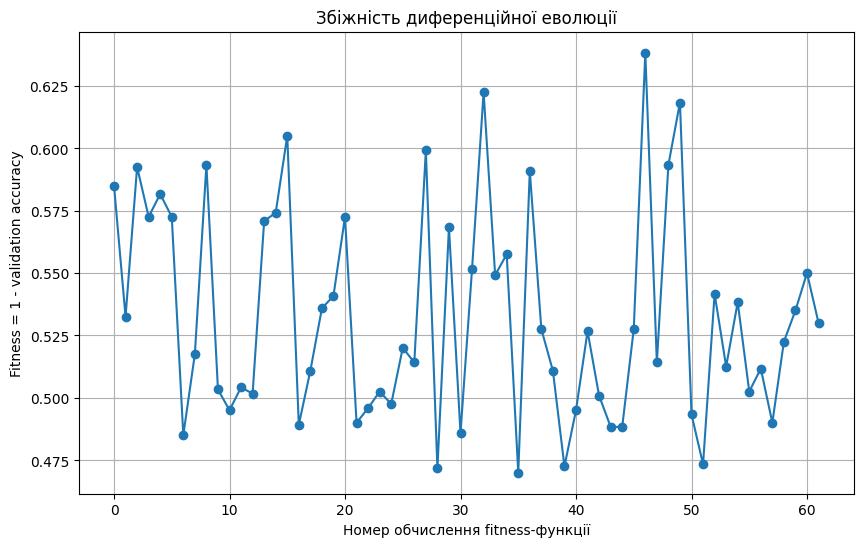

In [25]:
plt.plot(fitness_history, marker="o")
plt.xlabel("Номер обчислення fitness-функції")
plt.ylabel("Fitness = 1 - validation accuracy")
plt.title("Збіжність диференційної еволюції")
plt.show()

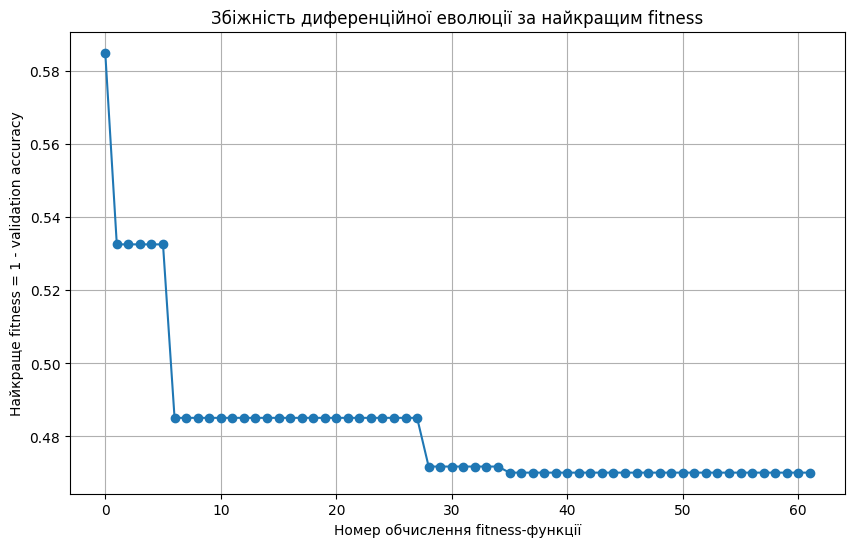

In [31]:
best_fitness_history = np.minimum.accumulate(fitness_history)

plt.plot(best_fitness_history, marker="o")
plt.xlabel("Номер обчислення fitness-функції")
plt.ylabel("Найкраще fitness = 1 - validation accuracy")
plt.title("Збіжність диференційної еволюції за найкращим fitness")
plt.show()

### 15. Графіки навчання найкращої моделі

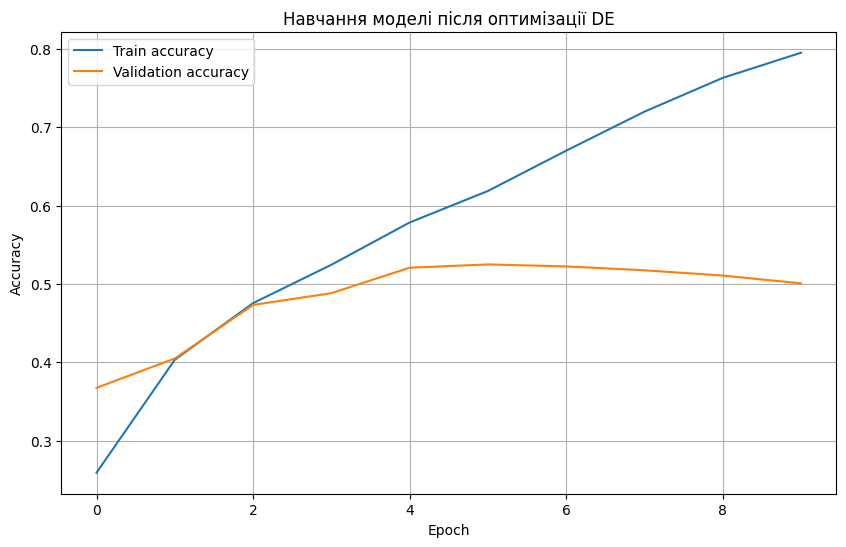

In [26]:
plt.plot(de_history.history["accuracy"], label="Train accuracy")
plt.plot(de_history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Навчання моделі після оптимізації DE")
plt.legend()
plt.show()

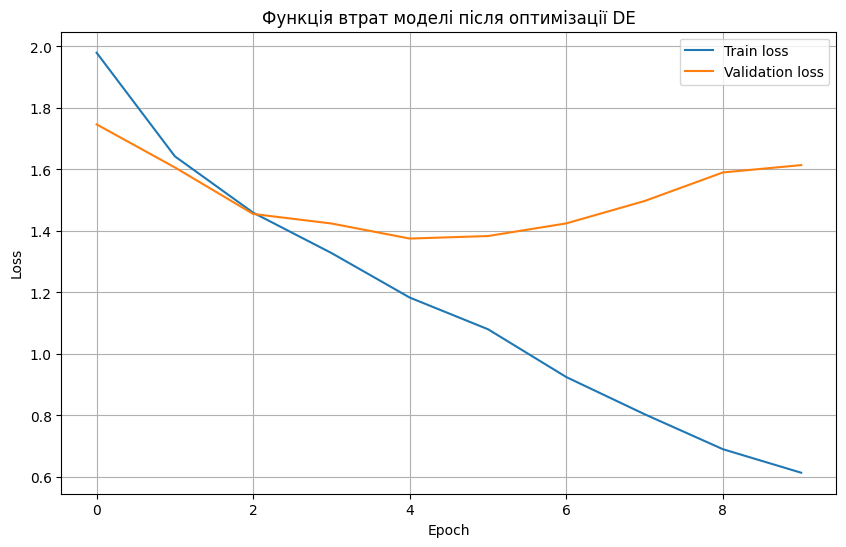

In [27]:
plt.plot(de_history.history["loss"], label="Train loss")
plt.plot(de_history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Функція втрат моделі після оптимізації DE")
plt.legend()
plt.show()

### 16. Матриця помилок

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


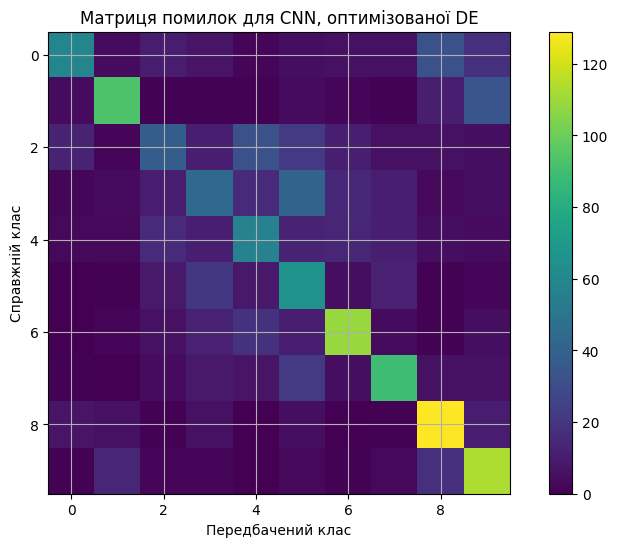

              precision    recall  f1-score   support

    airplane       0.66      0.40      0.49       149
  automobile       0.72      0.61      0.66       152
        bird       0.39      0.26      0.31       146
         cat       0.35      0.29      0.32       151
        deer       0.40      0.42      0.41       137
         dog       0.35      0.52      0.42       126
        frog       0.65      0.65      0.65       168
       horse       0.62      0.60      0.61       149
        ship       0.61      0.78      0.68       165
       truck       0.56      0.72      0.63       157

    accuracy                           0.53      1500
   macro avg       0.53      0.52      0.52      1500
weighted avg       0.54      0.53      0.53      1500



In [28]:
y_pred_probs = de_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Матриця помилок для CNN, оптимізованої DE")
plt.xlabel("Передбачений клас")
plt.ylabel("Справжній клас")
plt.colorbar()
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))

### 17. Ландшафт для двох параметрів

In [29]:
filter_values = [16, 24, 32, 48, 64]
learning_rate_values = np.logspace(-4, -2, 5)

landscape = np.zeros((len(filter_values), len(learning_rate_values)))

for i, filters in enumerate(filter_values):
    for j, lr in enumerate(learning_rate_values):
        
        model = build_cnn_model(
            filters=filters,
            dense_neurons=best_dense,
            dropout_rate=best_dropout,
            learning_rate=lr,
            optimizer_name="adam"
        )
        
        model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=5,
            batch_size=64,
            verbose=0
        )
        
        val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
        landscape[i, j] = val_acc
        
        print(f"filters={filters}, lr={lr:.5f}, val_acc={val_acc:.4f}")
        
        tf.keras.backend.clear_session()

filters=16, lr=0.00010, val_acc=0.3800
filters=16, lr=0.00032, val_acc=0.4475
filters=16, lr=0.00100, val_acc=0.5008
filters=16, lr=0.00316, val_acc=0.4858
filters=16, lr=0.01000, val_acc=0.3967
filters=24, lr=0.00010, val_acc=0.3850
filters=24, lr=0.00032, val_acc=0.4408
filters=24, lr=0.00100, val_acc=0.4808
filters=24, lr=0.00316, val_acc=0.5025
filters=24, lr=0.01000, val_acc=0.3158
filters=32, lr=0.00010, val_acc=0.4133
filters=32, lr=0.00032, val_acc=0.4783
filters=32, lr=0.00100, val_acc=0.5283
filters=32, lr=0.00316, val_acc=0.4875
filters=32, lr=0.01000, val_acc=0.1033
filters=48, lr=0.00010, val_acc=0.4267
filters=48, lr=0.00032, val_acc=0.4800
filters=48, lr=0.00100, val_acc=0.5150
filters=48, lr=0.00316, val_acc=0.4633
filters=48, lr=0.01000, val_acc=0.3967
filters=64, lr=0.00010, val_acc=0.4258
filters=64, lr=0.00032, val_acc=0.5050
filters=64, lr=0.00100, val_acc=0.5125
filters=64, lr=0.00316, val_acc=0.4942
filters=64, lr=0.01000, val_acc=0.3758


### 18. Візуалізація ландшафту

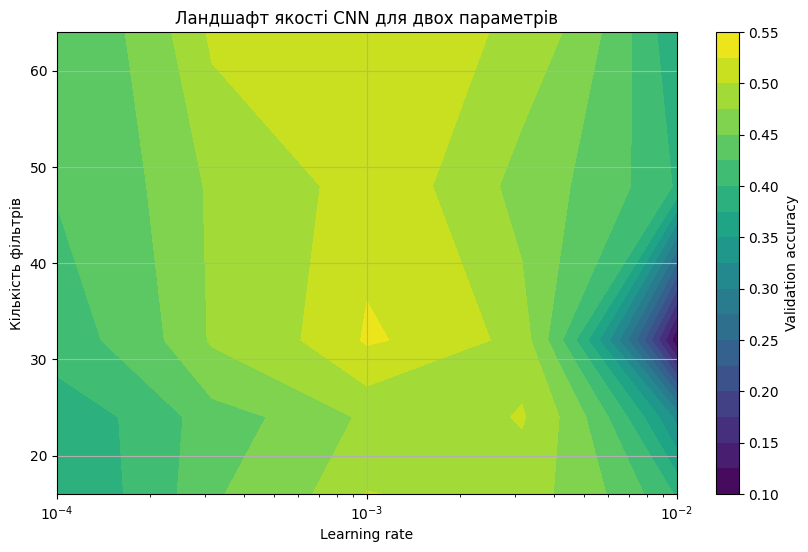

In [30]:
LR, F = np.meshgrid(learning_rate_values, filter_values)

plt.contourf(LR, F, landscape, levels=20)
plt.xscale("log")
plt.colorbar(label="Validation accuracy")
plt.xlabel("Learning rate")
plt.ylabel("Кількість фільтрів")
plt.title("Ландшафт якості CNN для двох параметрів")
plt.show()